# Fase 3 — Intervalos de Confianza

## Pregunta de negocio: ¿Con qué precisión estimamos métricas clave del taxi?

Los intervalos de confianza nos permiten cuantificar la **incertidumbre** en nuestras estimaciones. En lugar de reportar un solo número, proporcionamos un rango dentro del cual esperamos que se encuentre el verdadero parámetro poblacional.

**Dataset:** `bigquery-public-data.new_york_taxi_trips.tlc_yellow_trips_2015`

### Contenido
1. IC paramétrico para la media de tarifa (distribución t)
2. IC bootstrap para la mediana de tarifa
3. IC por zona (Manhattan, Brooklyn, JFK, LaGuardia, Queens)
4. Efecto del tamaño de muestra en el ancho del IC
5. IC para proporciones: porcentaje de viajes con propina > 20%
6. IC bootstrap para coeficiente de correlación (distancia vs tarifa)
7. Visualizaciones: error bars y funnel plot
8. Interpretación práctica

## 0. Configuración e importaciones

In [1]:
import sys
sys.path.insert(0, '../../../src')
from bigquery.bq_helper import BigQueryHelper
bq = BigQueryHelper()

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import t as t_dist
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')

print('Librerías cargadas correctamente.')

✓ Conectado a BigQuery - Proyecto: gen-lang-client-0180273702
✓ Cache en: /home/danielmf31/Documentos/Documentos_Trabajo/Ingenieria/Programacion/VSCode/Proyectos_personales/Ciencia_Datos/data/nyc_taxi/cache
Librerías cargadas correctamente.


### Carga de datos

Extraemos datos con información de zona para poder comparar entre áreas geográficas. Usamos `pickup_location_id` (TLC Zone ID) para clasificar las zonas principales.

In [2]:
query = """
SELECT
    fare_amount,
    trip_distance,
    tip_amount,
    total_amount,
    passenger_count,
    payment_type,
    pickup_location_id,
    pickup_datetime,
    EXTRACT(HOUR FROM pickup_datetime) AS pickup_hour,
    EXTRACT(DAYOFWEEK FROM pickup_datetime) AS pickup_dow,
    TIMESTAMP_DIFF(dropoff_datetime, pickup_datetime, MINUTE) AS trip_duration_min
FROM `bigquery-public-data.new_york_taxi_trips.tlc_yellow_trips_2015`
WHERE fare_amount > 0
    AND fare_amount < 200
    AND trip_distance > 0
    AND trip_distance < 100
    AND tip_amount >= 0
    AND passenger_count > 0
    AND pickup_location_id IS NOT NULL
    AND TIMESTAMP_DIFF(dropoff_datetime, pickup_datetime, MINUTE) > 0
    AND TIMESTAMP_DIFF(dropoff_datetime, pickup_datetime, MINUTE) < 180
ORDER BY RAND()
LIMIT 100000
"""

df = bq.query_to_df(query)
print(f'Registros cargados: {len(df):,}')
df.head()

📁 Cache hit: 65be189dd648.parquet (100,000 filas)
Registros cargados: 100,000


,fare_amount,trip_distance,tip_amount,total_amount,passenger_count,payment_type,pickup_location_id,pickup_datetime,pickup_hour,pickup_dow,trip_duration_min
0,17.0,3.30,0.00,17.80,3,2,230,2015-04-16 11:53:04+00:00,11,5,25
1,49.0,12.12,9.96,59.76,1,1,138,2015-05-26 15:01:20+00:00,15,3,70
2,17.5,3.50,3.66,21.96,1,1,90,2015-04-13 08:36:29+00:00,8,2,24
3,31.0,10.50,7.45,44.79,1,1,162,2015-06-18 08:43:41+00:00,8,5,22
4,13.5,2.40,2.86,17.16,1,1,211,2015-09-22 12:44:39+00:00,12,3,19


In [3]:
# Clasificar zonas basándose en pickup_location_id (TLC Zone IDs)
MANHATTAN_ZONES = {'4','12','13','24','41','42','43','45','48','50','68','74','75','79','87','88','90','100','107','113','114','116','125','127','128','137','140','141','142','143','144','148','151','152','153','158','161','162','163','164','166','170','186','194','202','209','211','224','229','230','231','232','233','234','236','237','238','239','243','244','246','249','261','262','263'}
BROOKLYN_ZONES = {'11','14','17','21','22','25','26','29','33','34','35','36','37','39','40','49','52','54','55','61','62','63','65','66','67','69','71','72','76','77','80','85','89','91','97','106','108','111','112','123','133','149','150','154','155','165','177','178','181','188','189','190','195','210','217','222','225','227','228','255','256','257'}
JFK_ZONE = {'132'}
LAGUARDIA_ZONE = {'138'}

def classify_zone(location_id):
    loc = str(location_id)
    if loc in JFK_ZONE:
        return 'JFK'
    elif loc in LAGUARDIA_ZONE:
        return 'LaGuardia'
    elif loc in MANHATTAN_ZONES:
        return 'Manhattan'
    elif loc in BROOKLYN_ZONES:
        return 'Brooklyn'
    else:
        return 'Otra'

df['zona'] = df['pickup_location_id'].apply(classify_zone)
print('Distribución por zona:')
print(df['zona'].value_counts())

# Calcular proporción de propina
df['tip_pct'] = np.where(df['fare_amount'] > 0, df['tip_amount'] / df['fare_amount'] * 100, 0)

Distribución por zona:
zona
Manhattan    90872
Otra          2651
LaGuardia     2392
JFK           2131
Brooklyn      1954
Name: count, dtype: int64


## 1. IC paramétrico para la media de tarifa (distribución t)

El intervalo de confianza paramétrico para la media utiliza la **distribución t de Student**. Es apropiado cuando la muestra es lo suficientemente grande (n > 30) por el Teorema del Límite Central, incluso si los datos no son normales.

**Fórmula:** IC = x̄ ± t_(α/2, n-1) × (s / √n)

In [4]:
fare = df['fare_amount'].dropna()

# IC al 95% usando distribución t
confidence = 0.95
n = len(fare)
mean = fare.mean()
se = fare.std(ddof=1) / np.sqrt(n)  # Error estándar

ci_low, ci_high = t_dist.interval(confidence, df=n-1, loc=mean, scale=se)

print(f'Intervalo de confianza paramétrico (t-Student) para la media de fare_amount')
print(f'=' * 65)
print(f'  Tamaño de muestra (n):  {n:,}')
print(f'  Media muestral (x̄):     ${mean:.4f}')
print(f'  Desv. estándar (s):      ${fare.std(ddof=1):.4f}')
print(f'  Error estándar (SE):     ${se:.4f}')
print(f'  Nivel de confianza:      {confidence*100:.0f}%')
print(f'  IC 95%:                  [${ci_low:.4f}, ${ci_high:.4f}]')
print(f'  Ancho del IC:            ${ci_high - ci_low:.4f}')
print(f'  Margen de error:         ±${(ci_high - ci_low)/2:.4f}')

# También calcular IC al 90% y 99%
for conf in [0.90, 0.95, 0.99]:
    lo, hi = t_dist.interval(conf, df=n-1, loc=mean, scale=se)
    print(f'\n  IC {conf*100:.0f}%: [${lo:.4f}, ${hi:.4f}] — Ancho: ${hi-lo:.4f}')

Intervalo de confianza paramétrico (t-Student) para la media de fare_amount
  Tamaño de muestra (n):  100,000
  Media muestral (x̄):     $12.8607
  Desv. estándar (s):      $10.4352
  Error estándar (SE):     $0.0330
  Nivel de confianza:      95%
  IC 95%:                  [$12.7960, $12.9254]
  Ancho del IC:            $0.1294
  Margen de error:         ±$0.0647

  IC 90%: [$12.8064, $12.9150] — Ancho: $0.1086

  IC 95%: [$12.7960, $12.9254] — Ancho: $0.1294

  IC 99%: [$12.7757, $12.9457] — Ancho: $0.1700


## 2. IC bootstrap para la mediana de tarifa

El **bootstrap** es un método no paramétrico: remuestreamos con reemplazo muchas veces y calculamos la estadística de interés en cada remuestra. Los percentiles de la distribución bootstrap nos dan el intervalo de confianza.

Esto es especialmente útil para la **mediana** y otras estadísticas donde no existe una fórmula paramétrica simple.

Intervalo de confianza bootstrap para la MEDIANA de fare_amount
  Número de remuestreos:   10,000
  Mediana muestral:        $9.5000
  Mediana bootstrap (prom):$9.5000
  IC 95% (percentiles):    [$9.5000, $9.5000]
  Ancho del IC:            $0.0000


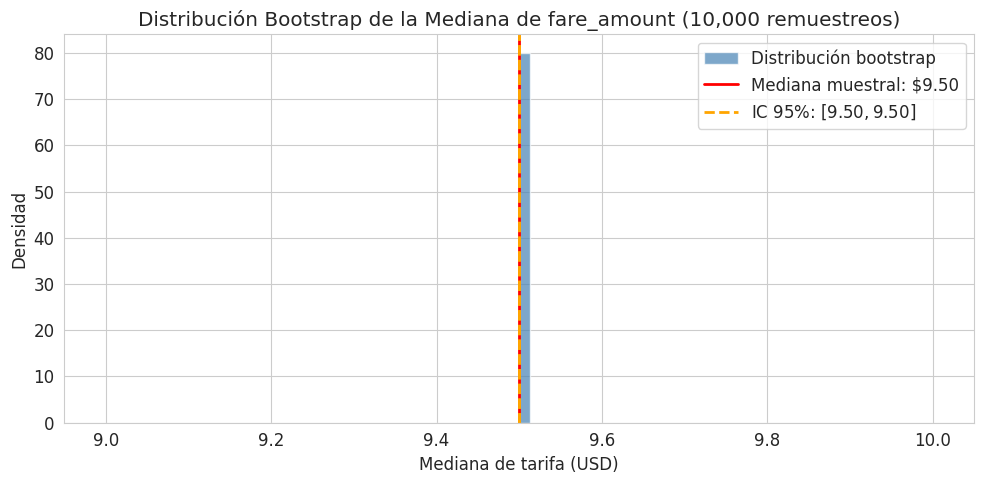

In [5]:
n_bootstrap = 10000
fare_values = fare.values

# Generar distribución bootstrap de la mediana
bootstrap_medians = np.array([
    np.median(np.random.choice(fare_values, size=len(fare_values), replace=True))
    for _ in range(n_bootstrap)
])

# IC por método de percentiles
ci_boot_low = np.percentile(bootstrap_medians, 2.5)
ci_boot_high = np.percentile(bootstrap_medians, 97.5)

print(f'Intervalo de confianza bootstrap para la MEDIANA de fare_amount')
print(f'=' * 60)
print(f'  Número de remuestreos:   {n_bootstrap:,}')
print(f'  Mediana muestral:        ${np.median(fare_values):.4f}')
print(f'  Mediana bootstrap (prom):${bootstrap_medians.mean():.4f}')
print(f'  IC 95% (percentiles):    [${ci_boot_low:.4f}, ${ci_boot_high:.4f}]')
print(f'  Ancho del IC:            ${ci_boot_high - ci_boot_low:.4f}')

# Visualizar distribución bootstrap
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(bootstrap_medians, bins=80, density=True, alpha=0.7, color='steelblue',
        edgecolor='white', label='Distribución bootstrap')
ax.axvline(np.median(fare_values), color='red', linewidth=2, linestyle='-',
           label=f'Mediana muestral: ${np.median(fare_values):.2f}')
ax.axvline(ci_boot_low, color='orange', linewidth=2, linestyle='--',
           label=f'IC 95%: [${ci_boot_low:.2f}, ${ci_boot_high:.2f}]')
ax.axvline(ci_boot_high, color='orange', linewidth=2, linestyle='--')
ax.set_xlabel('Mediana de tarifa (USD)')
ax.set_ylabel('Densidad')
ax.set_title('Distribución Bootstrap de la Mediana de fare_amount (10,000 remuestreos)')
ax.legend()
plt.tight_layout()
plt.show()

## 3. IC por zona (Manhattan, Brooklyn, JFK, LaGuardia, Queens)

Calculamos intervalos de confianza para la tarifa media en cada zona y comparamos sus anchos. Zonas con menos viajes tendrán intervalos más amplios, reflejando mayor incertidumbre.

In [6]:
zonas_principales = ['Manhattan', 'Brooklyn', 'JFK', 'LaGuardia', 'Queens']
df_zonas = df[df['zona'].isin(zonas_principales)].copy()

zone_results = []

print(f'{"Zona":<12} {"n":>8} {"Media":>10} {"IC 95% Inferior":>16} {"IC 95% Superior":>16} {"Ancho IC":>10}')
print('-' * 75)

for zona in zonas_principales:
    data = df_zonas[df_zonas['zona'] == zona]['fare_amount']
    n_z = len(data)
    
    if n_z < 2:
        continue
    
    mean_z = data.mean()
    se_z = data.std(ddof=1) / np.sqrt(n_z)
    ci_lo, ci_hi = t_dist.interval(0.95, df=n_z-1, loc=mean_z, scale=se_z)
    width = ci_hi - ci_lo
    
    zone_results.append({
        'zona': zona,
        'n': n_z,
        'mean': mean_z,
        'ci_low': ci_lo,
        'ci_high': ci_hi,
        'width': width
    })
    
    print(f'{zona:<12} {n_z:>8,} {mean_z:>10.2f} {ci_lo:>16.4f} {ci_hi:>16.4f} {width:>10.4f}')

zone_df = pd.DataFrame(zone_results)

Zona                n      Media  IC 95% Inferior  IC 95% Superior   Ancho IC
---------------------------------------------------------------------------
Manhattan      90,872      11.51          11.4537          11.5602     0.1065
Brooklyn        1,954      13.62          13.2192          14.0200     0.8008
JFK             2,131      46.66          46.0718          47.2554     1.1836
LaGuardia       2,392      32.01          31.5518          32.4715     0.9197


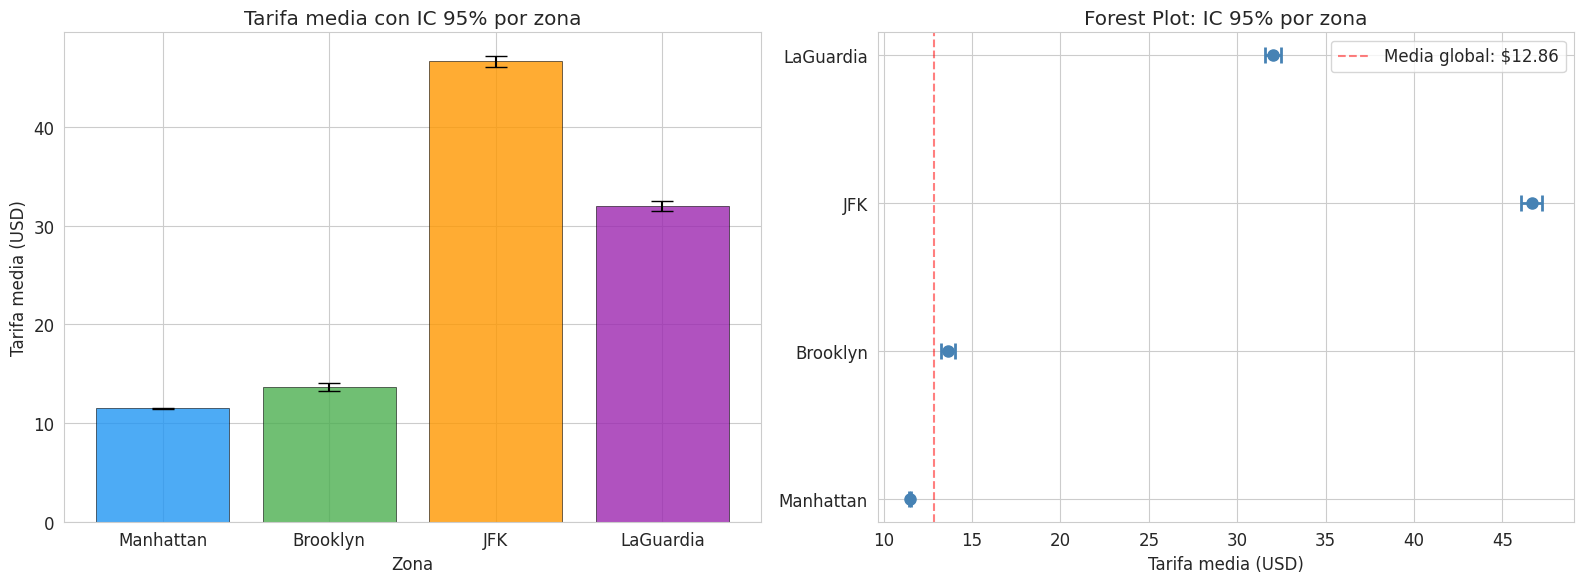


Observación: Las zonas de aeropuerto (JFK, LaGuardia) muestran tarifas medias
más altas y potencialmente intervalos más anchos por menor cantidad de viajes.


In [7]:
# Visualización: gráfico de barras de error por zona
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Error bars
colors = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0', '#F44336']
errors = [(zone_df['mean'] - zone_df['ci_low']).values,
          (zone_df['ci_high'] - zone_df['mean']).values]

axes[0].bar(zone_df['zona'], zone_df['mean'], yerr=errors, capsize=8,
            color=colors[:len(zone_df)], alpha=0.8, edgecolor='black', linewidth=0.5)
axes[0].set_ylabel('Tarifa media (USD)')
axes[0].set_title('Tarifa media con IC 95% por zona')
axes[0].set_xlabel('Zona')

# Horizontal error bar (forest plot style)
y_pos = range(len(zone_df))
axes[1].errorbar(zone_df['mean'], y_pos,
                 xerr=[zone_df['mean'] - zone_df['ci_low'],
                       zone_df['ci_high'] - zone_df['mean']],
                 fmt='o', color='steelblue', markersize=8, capsize=6,
                 capthick=2, linewidth=2)
axes[1].set_yticks(y_pos)
axes[1].set_yticklabels(zone_df['zona'])
axes[1].set_xlabel('Tarifa media (USD)')
axes[1].set_title('Forest Plot: IC 95% por zona')
axes[1].axvline(df['fare_amount'].mean(), color='red', linestyle='--', alpha=0.5,
                label=f'Media global: ${df["fare_amount"].mean():.2f}')
axes[1].legend()

plt.tight_layout()
plt.show()

print('\nObservación: Las zonas de aeropuerto (JFK, LaGuardia) muestran tarifas medias')
print('más altas y potencialmente intervalos más anchos por menor cantidad de viajes.')

## 4. Efecto del tamaño de muestra en el ancho del IC

A medida que aumentamos el tamaño de muestra (n), el error estándar disminuye como 1/√n, y por lo tanto el intervalo de confianza se vuelve más estrecho. Demostramos este principio fundamental.

In [8]:
sample_sizes = [100, 500, 1000, 5000, 10000, 50000]
n_repetitions = 200  # Repeticiones por tamaño
fare_pop = df['fare_amount'].dropna().values

ci_widths_results = []

print(f'{"n":>8} {"Ancho IC medio":>16} {"Ancho IC mediano":>18} {"DE del ancho":>14}')
print('-' * 60)

for n_s in sample_sizes:
    widths = []
    for _ in range(n_repetitions):
        sample = np.random.choice(fare_pop, size=n_s, replace=True)
        mean_s = sample.mean()
        se_s = sample.std(ddof=1) / np.sqrt(n_s)
        lo, hi = t_dist.interval(0.95, df=n_s-1, loc=mean_s, scale=se_s)
        widths.append(hi - lo)
    
    mean_width = np.mean(widths)
    median_width = np.median(widths)
    std_width = np.std(widths)
    
    ci_widths_results.append({
        'n': n_s,
        'mean_width': mean_width,
        'median_width': median_width,
        'std_width': std_width,
        'all_widths': widths
    })
    
    print(f'{n_s:>8,} {mean_width:>16.4f} {median_width:>18.4f} {std_width:>14.4f}')

       n   Ancho IC medio   Ancho IC mediano   DE del ancho
------------------------------------------------------------
     100           3.9502             3.9090         0.6850
     500           1.8330             1.8250         0.1681
   1,000           1.2921             1.2783         0.0782
   5,000           0.5777             0.5772         0.0164
  10,000           0.4093             0.4088         0.0078
  50,000           0.1829             0.1829         0.0015


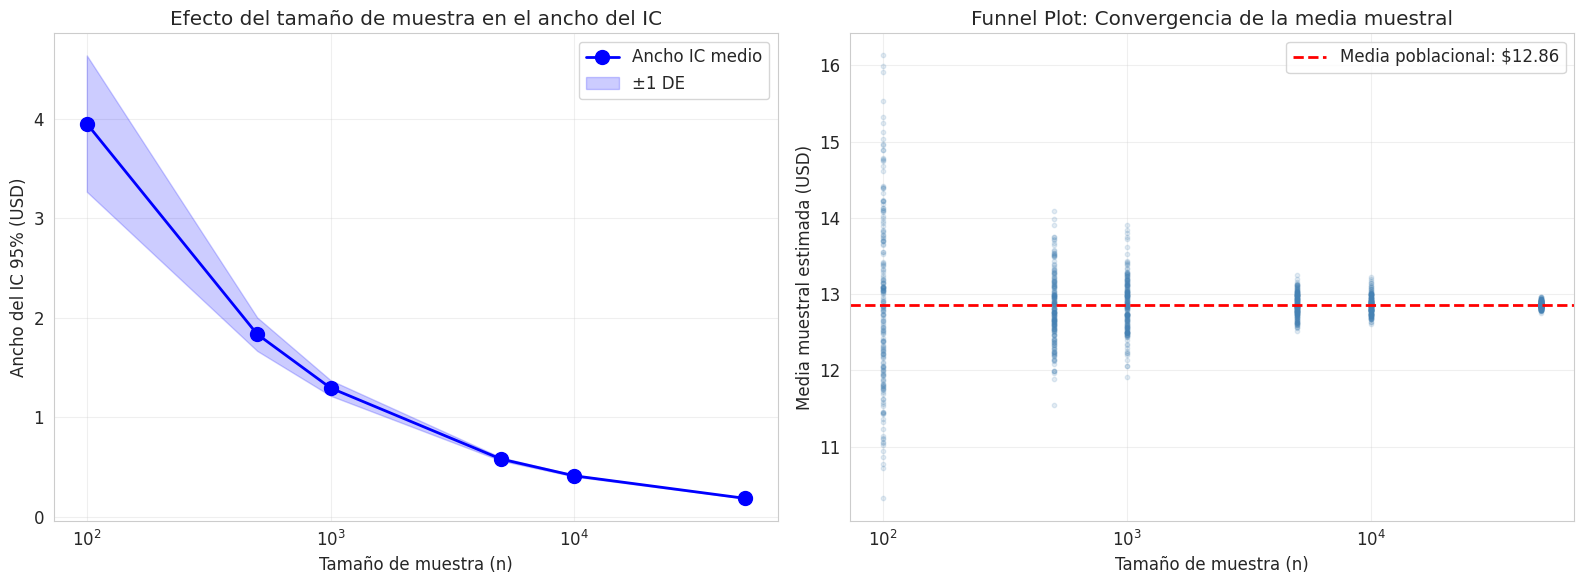


Verificación: el ancho del IC debería reducirse por factor √(n1/n2)
  n:    100 →    500  Factor n: 5.0x  Factor ancho: 2.16x  Teórico (√factor): 2.24x
  n:    500 →  1,000  Factor n: 2.0x  Factor ancho: 1.42x  Teórico (√factor): 1.41x
  n:  1,000 →  5,000  Factor n: 5.0x  Factor ancho: 2.24x  Teórico (√factor): 2.24x
  n:  5,000 → 10,000  Factor n: 2.0x  Factor ancho: 1.41x  Teórico (√factor): 1.41x
  n: 10,000 → 50,000  Factor n: 5.0x  Factor ancho: 2.24x  Teórico (√factor): 2.24x


In [9]:
# Visualización: Funnel plot (efecto del tamaño de muestra)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico 1: Ancho del IC vs tamaño de muestra
ns = [r['n'] for r in ci_widths_results]
mean_ws = [r['mean_width'] for r in ci_widths_results]
std_ws = [r['std_width'] for r in ci_widths_results]

axes[0].plot(ns, mean_ws, 'bo-', markersize=10, linewidth=2, label='Ancho IC medio')
axes[0].fill_between(ns,
                     [m - s for m, s in zip(mean_ws, std_ws)],
                     [m + s for m, s in zip(mean_ws, std_ws)],
                     alpha=0.2, color='blue', label='±1 DE')
axes[0].set_xlabel('Tamaño de muestra (n)')
axes[0].set_ylabel('Ancho del IC 95% (USD)')
axes[0].set_title('Efecto del tamaño de muestra en el ancho del IC')
axes[0].set_xscale('log')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Gráfico 2: Funnel plot (media estimada vs tamaño de muestra)
for r in ci_widths_results:
    n_s = r['n']
    # Recalcular medias para el funnel plot
    means = []
    for _ in range(200):
        sample = np.random.choice(fare_pop, size=n_s, replace=True)
        means.append(sample.mean())
    axes[1].scatter([n_s] * len(means), means, alpha=0.15, s=10, color='steelblue')

axes[1].axhline(fare_pop.mean(), color='red', linewidth=2, linestyle='--',
                label=f'Media poblacional: ${fare_pop.mean():.2f}')
axes[1].set_xlabel('Tamaño de muestra (n)')
axes[1].set_ylabel('Media muestral estimada (USD)')
axes[1].set_title('Funnel Plot: Convergencia de la media muestral')
axes[1].set_xscale('log')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Verificar relación teórica: ancho ∝ 1/√n
print('\nVerificación: el ancho del IC debería reducirse por factor √(n1/n2)')
for i in range(1, len(ci_widths_results)):
    ratio_n = ci_widths_results[i]['n'] / ci_widths_results[i-1]['n']
    ratio_w = ci_widths_results[i-1]['mean_width'] / ci_widths_results[i]['mean_width']
    print(f'  n: {ci_widths_results[i-1]["n"]:>6,} → {ci_widths_results[i]["n"]:>6,}  '
          f'Factor n: {ratio_n:.1f}x  Factor ancho: {ratio_w:.2f}x  '
          f'Teórico (√factor): {np.sqrt(ratio_n):.2f}x')

## 5. IC para proporciones: porcentaje de viajes con propina > 20%

Para proporciones, podemos construir un intervalo de confianza usando la **aproximación normal**:

IC = p̂ ± z_(α/2) × √(p̂(1-p̂)/n)

donde p̂ es la proporción muestral.

In [10]:
# Solo viajes con tarjeta de crédito (propinas registradas)
df_credit = df[(df['payment_type'] == '1') | (df['payment_type'] == 1)].copy()
df_credit = df_credit[df_credit['fare_amount'] > 0]

# Proporción con propina > 20% del fare
high_tip = (df_credit['tip_pct'] > 20).astype(int)
n_prop = len(high_tip)
p_hat = high_tip.mean()

# Error estándar para proporción
se_prop = np.sqrt(p_hat * (1 - p_hat) / n_prop)

# IC usando aproximación normal
z_95 = stats.norm.ppf(0.975)
ci_prop_low = p_hat - z_95 * se_prop
ci_prop_high = p_hat + z_95 * se_prop

print(f'Intervalo de confianza para la proporción de viajes con propina > 20%')
print(f'(Solo pagos con tarjeta de crédito)')
print(f'=' * 60)
print(f'  Viajes analizados:       {n_prop:,}')
print(f'  Viajes con tip > 20%:    {high_tip.sum():,}')
print(f'  Proporción muestral (p̂): {p_hat:.4f} ({p_hat*100:.2f}%)')
print(f'  Error estándar:          {se_prop:.6f}')
print(f'  z (95%):                 {z_95:.4f}')
print(f'  IC 95%:                  [{ci_prop_low:.4f}, {ci_prop_high:.4f}]')
print(f'                           [{ci_prop_low*100:.2f}%, {ci_prop_high*100:.2f}%]')

# IC por zona
print(f'\nIC para proporción de propina > 20% por zona:')
print(f'{"Zona":<12} {"n":>8} {"p̂ (%)":>10} {"IC inferior":>12} {"IC superior":>12}')
print('-' * 56)

for zona in zonas_principales:
    data_z = df_credit[df_credit['zona'] == zona]
    if len(data_z) < 30:
        continue
    high_z = (data_z['tip_pct'] > 20).astype(int)
    n_z = len(high_z)
    p_z = high_z.mean()
    se_z = np.sqrt(p_z * (1 - p_z) / n_z)
    lo_z = p_z - z_95 * se_z
    hi_z = p_z + z_95 * se_z
    print(f'{zona:<12} {n_z:>8,} {p_z*100:>10.2f} {lo_z*100:>12.2f}% {hi_z*100:>12.2f}%')

Intervalo de confianza para la proporción de viajes con propina > 20%
(Solo pagos con tarjeta de crédito)
  Viajes analizados:       62,931
  Viajes con tip > 20%:    43,877
  Proporción muestral (p̂): 0.6972 (69.72%)
  Error estándar:          0.001832
  z (95%):                 1.9600
  IC 95%:                  [0.6936, 0.7008]
                           [69.36%, 70.08%]

IC para proporción de propina > 20% por zona:
Zona                n     p̂ (%)  IC inferior  IC superior
--------------------------------------------------------
Manhattan      57,351      69.55        69.18%        69.93%
Brooklyn        1,181      73.50        70.98%        76.01%
JFK             1,220      66.23        63.58%        68.88%
LaGuardia       1,759      76.86        74.89%        78.83%


## 6. IC bootstrap para coeficiente de correlación (distancia vs tarifa)

El coeficiente de correlación de Pearson no tiene un IC paramétrico simple (se usa la transformación de Fisher, pero es compleja). El bootstrap es una alternativa elegante y directa.

Correlación muestral (Pearson): r = 0.953261

IC Bootstrap 95% para correlación (distancia vs tarifa):
  [0.949948, 0.956158]
  Ancho: 0.006209


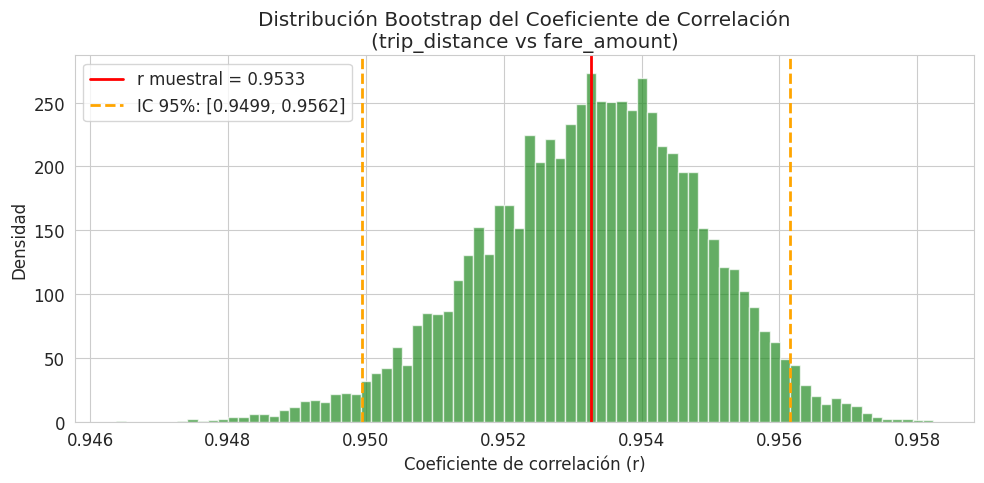

In [11]:
# Datos para correlación
df_corr = df[['trip_distance', 'fare_amount']].dropna()
df_corr = df_corr[(df_corr['trip_distance'] > 0) & (df_corr['fare_amount'] > 0)]

# Correlación muestral
r_sample = df_corr['trip_distance'].corr(df_corr['fare_amount'])
print(f'Correlación muestral (Pearson): r = {r_sample:.6f}')

# Bootstrap
n_boot = 10000
n_corr = len(df_corr)
boot_correlations = []

for _ in range(n_boot):
    idx = np.random.choice(n_corr, size=n_corr, replace=True)
    boot_sample = df_corr.iloc[idx]
    r_boot = boot_sample['trip_distance'].corr(boot_sample['fare_amount'])
    boot_correlations.append(r_boot)

boot_correlations = np.array(boot_correlations)

ci_r_low = np.percentile(boot_correlations, 2.5)
ci_r_high = np.percentile(boot_correlations, 97.5)

print(f'\nIC Bootstrap 95% para correlación (distancia vs tarifa):')
print(f'  [{ci_r_low:.6f}, {ci_r_high:.6f}]')
print(f'  Ancho: {ci_r_high - ci_r_low:.6f}')

# Visualización
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(boot_correlations, bins=80, density=True, alpha=0.7, color='forestgreen',
        edgecolor='white')
ax.axvline(r_sample, color='red', linewidth=2, label=f'r muestral = {r_sample:.4f}')
ax.axvline(ci_r_low, color='orange', linewidth=2, linestyle='--',
           label=f'IC 95%: [{ci_r_low:.4f}, {ci_r_high:.4f}]')
ax.axvline(ci_r_high, color='orange', linewidth=2, linestyle='--')
ax.set_xlabel('Coeficiente de correlación (r)')
ax.set_ylabel('Densidad')
ax.set_title('Distribución Bootstrap del Coeficiente de Correlación\n(trip_distance vs fare_amount)')
ax.legend()
plt.tight_layout()
plt.show()

## 7. Visualizaciones consolidadas: error bars y funnel plot

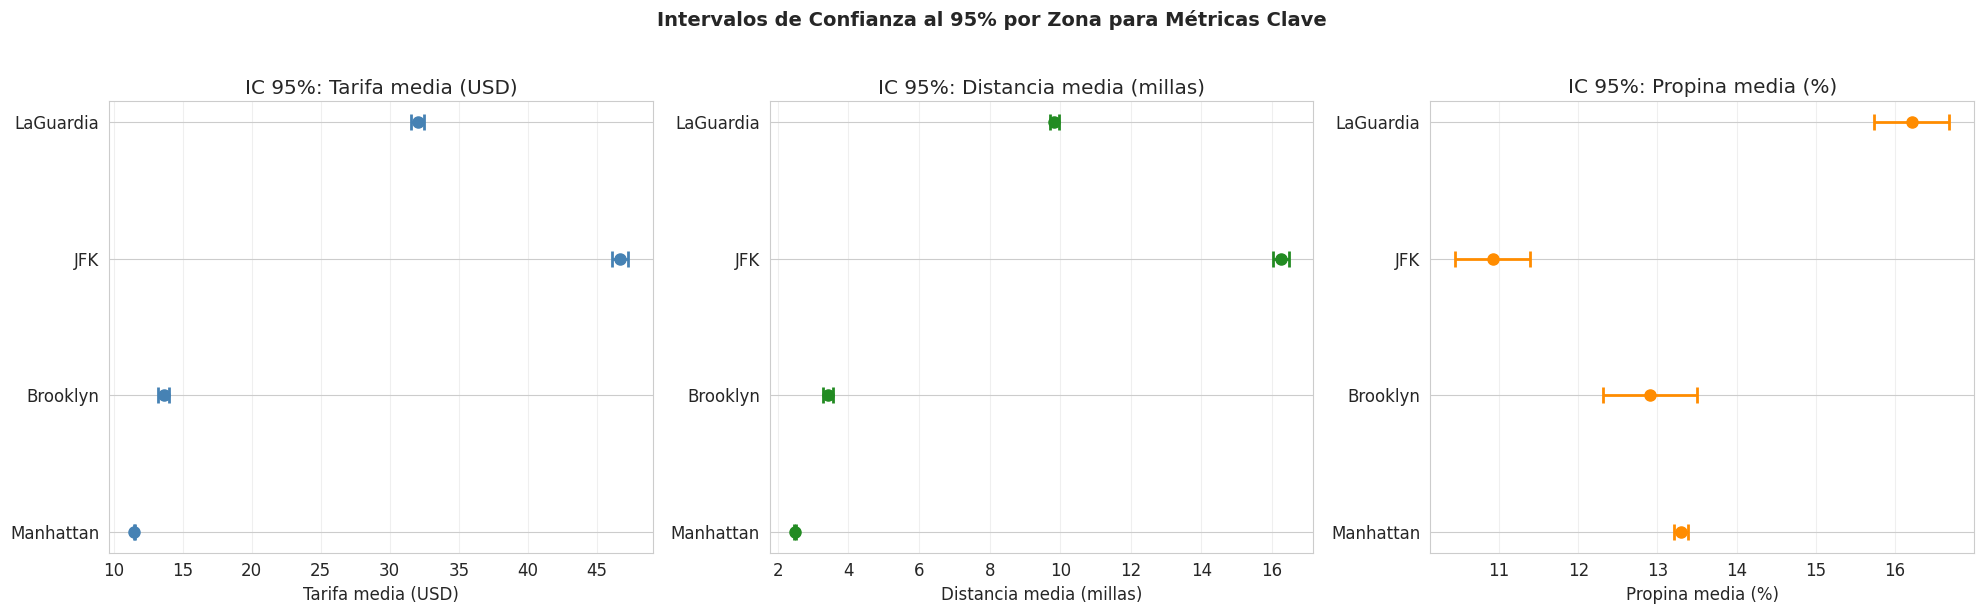

In [12]:
# Gráfico consolidado: IC para múltiples métricas por zona
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

metricas = [
    ('fare_amount', 'Tarifa media (USD)', 'steelblue'),
    ('trip_distance', 'Distancia media (millas)', 'forestgreen'),
    ('tip_pct', 'Propina media (%)', 'darkorange')
]

for ax, (col, label, color) in zip(axes, metricas):
    means_z = []
    ci_lows_z = []
    ci_highs_z = []
    zonas_plot = []
    
    for zona in zonas_principales:
        data_z = df_zonas[df_zonas['zona'] == zona][col].dropna()
        if len(data_z) < 30:
            continue
        n_z = len(data_z)
        m_z = data_z.mean()
        se_z = data_z.std(ddof=1) / np.sqrt(n_z)
        lo, hi = t_dist.interval(0.95, df=n_z-1, loc=m_z, scale=se_z)
        means_z.append(m_z)
        ci_lows_z.append(lo)
        ci_highs_z.append(hi)
        zonas_plot.append(zona)
    
    means_z = np.array(means_z)
    ci_lows_z = np.array(ci_lows_z)
    ci_highs_z = np.array(ci_highs_z)
    
    y_pos = range(len(zonas_plot))
    ax.errorbar(means_z, y_pos,
                xerr=[means_z - ci_lows_z, ci_highs_z - means_z],
                fmt='o', color=color, markersize=8, capsize=6,
                capthick=2, linewidth=2)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(zonas_plot)
    ax.set_xlabel(label)
    ax.set_title(f'IC 95%: {label}')
    ax.grid(True, alpha=0.3, axis='x')

plt.suptitle('Intervalos de Confianza al 95% por Zona para Métricas Clave',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 8. Interpretación práctica

Los intervalos de confianza tienen una interpretación precisa que a menudo se confunde. Aquí aclaramos qué significan nuestros resultados.

In [13]:
print('=' * 80)
print('INTERPRETACIÓN PRÁCTICA DE LOS INTERVALOS DE CONFIANZA')
print('=' * 80)

print(f'''
1. TARIFA MEDIA GENERAL:
   "Tenemos un 95% de confianza de que la tarifa media verdadera de todos los
   viajes en taxi de NYC en 2015 se encuentra entre ${ci_low:.2f} y ${ci_high:.2f}."

   Interpretación correcta: Si repitiéramos este muestreo 100 veces,
   aproximadamente 95 de los intervalos construidos contendrían la media real.

2. MEDIANA DE TARIFA (Bootstrap):
   "Tenemos un 95% de confianza de que la mediana verdadera de la tarifa
   se encuentra entre ${ci_boot_low:.2f} y ${ci_boot_high:.2f}."

   El bootstrap es especialmente útil aquí porque no requiere
   supuestos sobre la distribución de los datos.

3. PROPORCIONES:
   "Tenemos un 95% de confianza de que entre el {ci_prop_low*100:.1f}% y el
   {ci_prop_high*100:.1f}% de los viajes con tarjeta reciben una propina
   superior al 20% de la tarifa."

4. CORRELACIÓN (distancia vs tarifa):
   "Tenemos un 95% de confianza de que la correlación verdadera entre la
   distancia y la tarifa se encuentra entre {ci_r_low:.4f} y {ci_r_high:.4f}."
   La correlación es fuerte y positiva en todos los escenarios bootstrap.

5. HALLAZGO CLAVE — Tamaño de muestra:
   Duplicar n reduce el ancho del IC por un factor de √2 ≈ 1.41.
   Para reducir el IC a la mitad, necesitamos 4x más datos.
   Esto tiene implicaciones directas en costos de recolección de datos.
''')

print('=' * 80)
print('TABLA RESUMEN DE TODOS LOS INTERVALOS DE CONFIANZA')
print('=' * 80)

summary = pd.DataFrame([
    {'Métrica': 'Media tarifa (paramétrico)',
     'Estimación puntual': f'${mean:.2f}',
     'IC 95% Inferior': f'${ci_low:.2f}',
     'IC 95% Superior': f'${ci_high:.2f}',
     'Método': 't-Student'},
    {'Métrica': 'Mediana tarifa (bootstrap)',
     'Estimación puntual': f'${np.median(fare_values):.2f}',
     'IC 95% Inferior': f'${ci_boot_low:.2f}',
     'IC 95% Superior': f'${ci_boot_high:.2f}',
     'Método': 'Bootstrap (10K)'},
    {'Métrica': 'Proporción tip > 20%',
     'Estimación puntual': f'{p_hat*100:.2f}%',
     'IC 95% Inferior': f'{ci_prop_low*100:.2f}%',
     'IC 95% Superior': f'{ci_prop_high*100:.2f}%',
     'Método': 'Aprox. Normal'},
    {'Métrica': 'Correlación dist-tarifa',
     'Estimación puntual': f'{r_sample:.4f}',
     'IC 95% Inferior': f'{ci_r_low:.4f}',
     'IC 95% Superior': f'{ci_r_high:.4f}',
     'Método': 'Bootstrap (10K)'},
])

summary

INTERPRETACIÓN PRÁCTICA DE LOS INTERVALOS DE CONFIANZA

1. TARIFA MEDIA GENERAL:
   "Tenemos un 95% de confianza de que la tarifa media verdadera de todos los
   viajes en taxi de NYC en 2015 se encuentra entre $12.80 y $12.93."

   Interpretación correcta: Si repitiéramos este muestreo 100 veces,
   aproximadamente 95 de los intervalos construidos contendrían la media real.

2. MEDIANA DE TARIFA (Bootstrap):
   "Tenemos un 95% de confianza de que la mediana verdadera de la tarifa
   se encuentra entre $9.50 y $9.50."

   El bootstrap es especialmente útil aquí porque no requiere
   supuestos sobre la distribución de los datos.

3. PROPORCIONES:
   "Tenemos un 95% de confianza de que entre el 69.4% y el
   70.1% de los viajes con tarjeta reciben una propina
   superior al 20% de la tarifa."

4. CORRELACIÓN (distancia vs tarifa):
   "Tenemos un 95% de confianza de que la correlación verdadera entre la
   distancia y la tarifa se encuentra entre 0.9499 y 0.9562."
   La correlación es fue

,Métrica,Estimación puntual,IC 95% Inferior,IC 95% Superior,Método
0,Media tarifa (paramétrico),$12.86,$12.80,$12.93,t-Student
1,Mediana tarifa (bootstrap),$9.50,$9.50,$9.50,Bootstrap (10K)
2,Proporción tip > 20%,69.72%,69.36%,70.08%,Aprox. Normal
3,Correlación dist-tarifa,0.9533,0.9499,0.9562,Bootstrap (10K)
